# Testing BCRP ANALYZER CLASS

In [1]:
import sys
from datetime import datetime as dt
from functools import reduce

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from bcrp_analytics.bcrp_analyzer import BCRP_ANALYZER
from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use(catppuccin.PALETTE.mocha.identifier)

# Importing data

In [2]:
# series to test
adquirentes_facilitadores_pago_series = {
    "PN42689EM": "monto_total_adqfac",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
}

In [3]:
df_adquirentes_facilitadores = build_bcrp_dataset(adquirentes_facilitadores_pago_series)

In [4]:
df_adquirentes_facilitadores.head()

,period,monto_total_adqfac,alto_valor,bajo_valor
0,2026-03-01,"13,167.96","478,458.55","417,155.45"
1,2026-02-01,"11,697.08","411,779.84","377,297.19"
2,2026-01-01,"12,252.01","398,930.84","394,384.29"
3,2025-12-01,"14,927.05","462,444.46","458,953.59"
4,2025-11-01,"12,200.23","398,541.09","374,481.11"


# Testing BCRP_ANALYZER

In [5]:
test_bcrp_analyzer = BCRP_ANALYZER()

Loading BCRP data...
BCRP data loaded!


In [6]:
test_bcrp_analyzer.df_ipc_series.tail()

,period,ipc,ipc_desestacionalizado,inflacion_mensual,inflacion_acumulada,inflacion_12m
4,2025-12-01,115.89,116.12,0.24,1.51,1.51
3,2026-01-01,116.01,116.35,0.10,0.10,1.70
2,2026-02-01,116.81,117.14,0.69,0.79,2.21
1,2026-03-01,119.59,119.28,2.38,3.19,3.80
0,2026-04-01,120.21,119.91,0.52,3.72,4.01


In [7]:
df_adquirentes_facilitadores["monto_total_adqfac_desestacionalziado"] = (
    test_bcrp_analyzer.deflate_series(
        df_adquirentes_facilitadores["monto_total_adqfac"]
    )
)
df_adquirentes_facilitadores.head()

,period,monto_total_adqfac,alto_valor,bajo_valor,monto_total_adqfac_desestacionalziado
0,2026-03-01,"13,167.96","478,458.55","417,155.45","10,953.99"
1,2026-02-01,"11,697.08","411,779.84","377,297.19","9,781.08"
2,2026-01-01,"12,252.01","398,930.84","394,384.29","10,488.81"
3,2025-12-01,"14,927.05","462,444.46","458,953.59","12,867.52"
4,2025-11-01,"12,200.23","398,541.09","374,481.11","10,527.00"


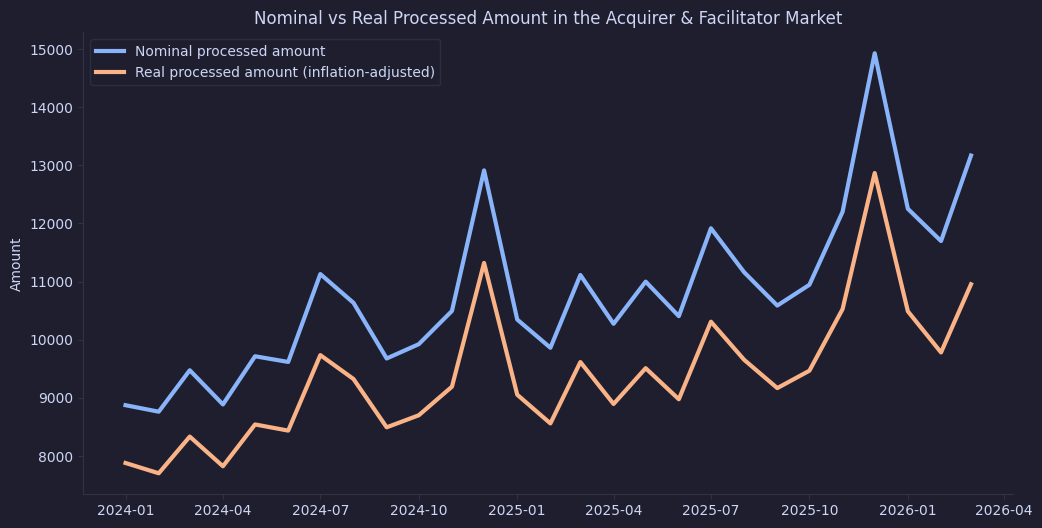

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_adquirentes_facilitadores["period"],
    df_adquirentes_facilitadores["monto_total_adqfac"],
    label="Nominal processed amount",
    linewidth=3,
)

ax.plot(
    df_adquirentes_facilitadores["period"],
    df_adquirentes_facilitadores["monto_total_adqfac_desestacionalziado"],
    label="Real processed amount (inflation-adjusted)",
    linewidth=3,
)

ax.set_title("Nominal vs Real Processed Amount in the Acquirer & Facilitator Market")

ax.set_ylabel("Amount")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [9]:
df_adquirentes_facilitadores = df_adquirentes_facilitadores.sort_values(
    "period"
).reset_index(drop=True)

df_adquirentes_facilitadores["real_monthly_growth"] = (
    test_bcrp_analyzer.calculate_real_monthly_growth(
        df_adquirentes_facilitadores, "period", "monto_total_adqfac"
    )
)
df_adquirentes_facilitadores.tail()

,period,monto_total_adqfac,alto_valor,bajo_valor,monto_total_adqfac_desestacionalziado,real_monthly_growth
55,2025-11-01,"12,200.23","398,541.09","374,481.11","10,527.00",11.35
56,2025-12-01,"14,927.05","462,444.46","458,953.59","12,867.52",22.05
57,2026-01-01,"12,252.01","398,930.84","394,384.29","10,488.81",-18.00
58,2026-02-01,"11,697.08","411,779.84","377,297.19","9,781.08",-5.19
59,2026-03-01,"13,167.96","478,458.55","417,155.45","10,953.99",9.96


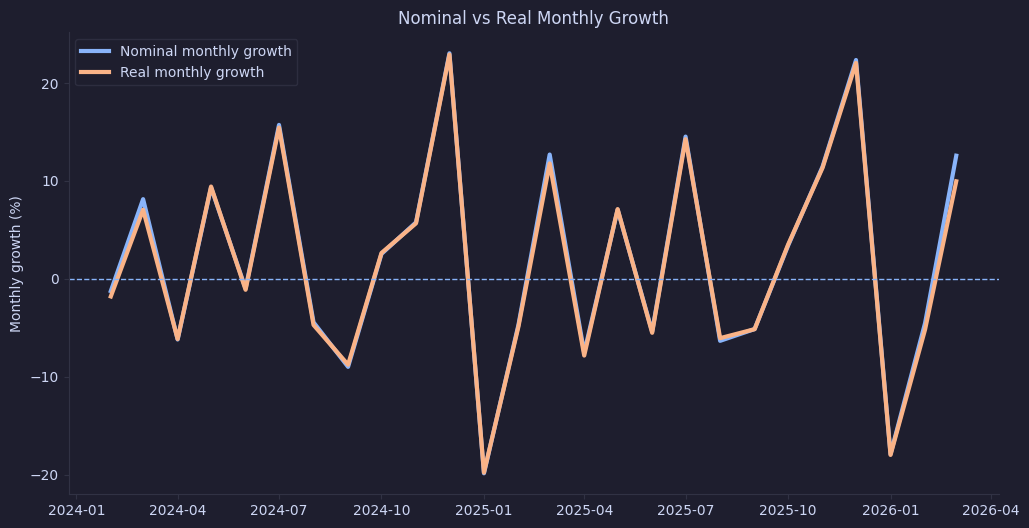

In [10]:
df_growth = df_adquirentes_facilitadores.sort_values("period").copy()

# nominal monthly growth
df_growth["nominal_growth"] = (df_growth["monto_total_adqfac"].pct_change()) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_growth["period"],
    df_growth["nominal_growth"],
    label="Nominal monthly growth",
    linewidth=3,
)

ax.plot(
    df_growth["period"],
    df_growth["real_monthly_growth"],
    label="Real monthly growth",
    linewidth=3,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Nominal vs Real Monthly Growth")

ax.set_ylabel("Monthly growth (%)")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [11]:
df_adquirentes_facilitadores = df_adquirentes_facilitadores.sort_values("period")
df_adquirentes_facilitadores["real_monthly_growth"] = (
    test_bcrp_analyzer.calculate_real_12m_growth(
        df_adquirentes_facilitadores, "period", "monto_total_adqfac"
    )
)
df_adquirentes_facilitadores.tail()

,period,monto_total_adqfac,alto_valor,bajo_valor,monto_total_adqfac_desestacionalziado,real_monthly_growth
55,2025-11-01,"12,200.23","398,541.09","374,481.11","10,527.00",14.68
56,2025-12-01,"14,927.05","462,444.46","458,953.59","12,867.52",13.88
57,2026-01-01,"12,252.01","398,930.84","394,384.29","10,488.81",16.43
58,2026-02-01,"11,697.08","411,779.84","377,297.19","9,781.08",16.04
59,2026-03-01,"13,167.96","478,458.55","417,155.45","10,953.99",14.15


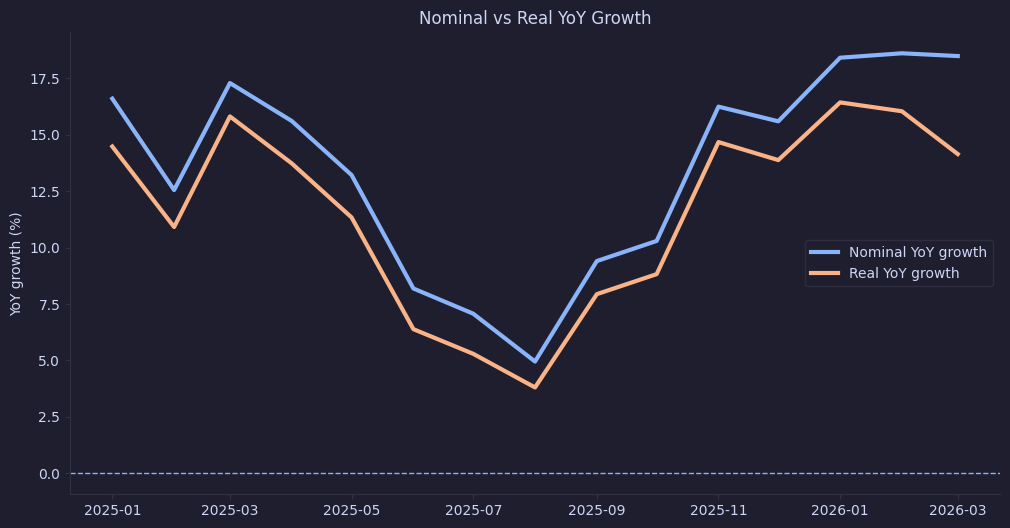

In [12]:
df_growth = df_adquirentes_facilitadores.sort_values("period").copy()

# nominal YoY growth
df_growth["nominal_yoy_growth"] = (df_growth["monto_total_adqfac"].pct_change(12)) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_growth["period"],
    df_growth["nominal_yoy_growth"],
    label="Nominal YoY growth",
    linewidth=3,
)

ax.plot(
    df_growth["period"],
    df_growth["real_monthly_growth"],
    label="Real YoY growth",
    linewidth=3,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Nominal vs Real YoY Growth")

ax.set_ylabel("YoY growth (%)")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()